In [1]:
import os
import warnings

import duckdb
import pandas as pd
from uszipcode import SearchEngine

# from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")


C:\Users\bhavy\miniconda3\envs\truck_cap\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [2]:
path = r"C:\Users\bhavy\Massachusetts Institute of Technology\Truck Parking Capstone - General\Truck Stop Finder 🚚⛽\\"
# path = r"C:\Users\samcl\Massachusetts Institute of Technology\Truck Parking Capstone - Truck Stop Finder 🚚⛽\\"

In [86]:
sensor_loc = pd.read_csv(path + r"5. Source & Refrence Files\sensor_loc_w_ZIP5.csv",
                         dtype={"station_id": 'str', 'ZIP5': 'str'})
state_map = pd.read_csv(path + r"5. Source & Refrence Files\State_mapping.csv")
model_stop = pd.read_excel("output_excel/Model_Stops_V3.xlsx")
traffic_df = pd.read_csv(path + r"4. Working Data Files\Traffic Files\Capstone_truck\merged_filtered_modified.csv")


In [4]:
sensor_loc = sensor_loc[sensor_loc["State"] != "AK"].copy()

In [5]:
# search = SearchEngine()
#
# def get_zip(row):
#     r = search.by_coordinates(row['Latitude'], row['Longitude'], radius=60, returns=1)
#     return r[0].zipcode if r else None
#
# sensor_loc['ZIP5'] = sensor_loc.apply(get_zip, axis=1)

In [6]:
sensor_loc

,Latitude,Longitude,Functional Class,State,Station Id,ZIP5
0,36.719788,-104.535744,4R,NM,WHIT01,87740
1,40.485651,-74.426438,3U,NJ,W41024,08901
2,40.892000,-74.223000,3U,NJ,W21035,07512
3,39.771974,-74.901328,3U,NJ,W07140,08009
4,39.944480,-74.095954,3U,NJ,W06108,08751
...,...,...,...,...,...,...
7930,34.710839,-76.736897,4U,NC,0A1501,28557
7931,35.551341,-82.731234,1U,NC,0A1003,28715
7932,33.937646,-78.555950,7U,NC,0A0901,28467
7933,35.946988,-82.004388,3R,NC,0A0501,28777


In [7]:
sensor_loc.columns

Index(['Latitude', 'Longitude', 'Functional Class', 'State', 'Station Id',
       'ZIP5'],
      dtype='object')

In [8]:
# traffic_df["link_id"] = traffic_df["routeid"].astype("str") + "_" + traffic_df["beginpoint"].astype("str") + "_" + \
#                         traffic_df["endpoint"].astype("str")
# in_link = traffic_df[traffic_df["link_id"].isin(model_stop["link_id"].unique())][["link_id", "MID_LAT", "MID_LONG"]]
#
# sensor_stops = pd.merge(in_link, sensor_loc, how="cross")
#
# sensor_stops['distance_miles'] = haversine_vector(sensor_stops[['Latitude', 'Longitude']],
#                                                   sensor_stops[['MID_LAT', 'MID_LONG']],
#                                                   Unit.MILES
#                                                   ) * 1.16
#
# #Finding nearest road segment to every stop
# idx = sensor_stops.groupby('link_id')['distance_miles'].idxmin()
# nearest = sensor_stops.loc[idx].reset_index()
# nearest = nearest[['Latitude', 'Longitude', 'Functional Class', 'State', 'Station Id', 'link_id']].copy()
# nearest

In [9]:
# folder = path + r"5. Source & Refrence Files\2024_traffic_data"
# out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
# os.makedirs(out_dir, exist_ok=True)
#
# # build mapping dict ONCE from your state_map df
# state_dict = state_map.set_index("state_code")["State"].to_dict()
#
# id_var_col = [
#     'record_type', 'state_code', 'f_system', 'station_id', 'travel_dir',
#     'travel_lane', 'year_record', 'month_record', 'day_record',
#     'day_of_week', 'restrictions'
# ]
#
# part = 0
#
# for filename in os.listdir(folder):
#     file_path = os.path.join(folder, filename)
#
#     if not filename.lower().endswith(".zip"):
#         continue
#
#     print(f"Opening ZIP: {filename}")
#
#     with zipfile.ZipFile(file_path, 'r') as z:
#         for inner_name in z.namelist():
#             if inner_name.endswith("/"):
#                 continue
#
#             print(f"  Processing inside ZIP: {inner_name}")
#
#             with z.open(inner_name) as f:
#                 # Read CSV from inside the ZIP
#                 df = pd.read_csv(
#                     f,
#                     delimiter="|",
#                     low_memory=False  # avoids dtype warning at cost of some RAM, OK for chunk
#                     # You can also pass dtype={} here if you know them
#                 )
#
#                 # Melt wide hours columns into long format
#                 df = pd.melt(
#                     df,
#                     id_vars=id_var_col,
#                     var_name="hours",
#                     value_name="traffic"
#                 )
#
#                 # Add state_name via map instead of big merge later
#                 df["State"] = df["state_code"].map(state_dict)
#                 df["station_id"] = df["station_id"].astype(str)
#
#                 # Save this chunk to Parquet and drop from memory
#                 out_path = os.path.join(out_dir, f"traffic_part_{part}.parquet")
#                 df.to_parquet(out_path, index=False)
#                 # print(f"    → wrote {out_path}")
#
#                 del df
#                 part += 1
#
# print(f"Done. Wrote {part} parquet files to {out_dir}")


In [10]:
traffic_df = pd.DataFrame()

In [11]:
out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
traffic_parquet_glob = f"{out_dir}/traffic_part_*.parquet"

In [12]:
con = duckdb.connect()
con.register("sensor_loc", sensor_loc)

In [13]:
out_dir = os.path.join(path, r"5. Source & Refrence Files\2024_traffic_parquet")
traffic_parquet_glob = f"{out_dir}/traffic_part_*.parquet"

In [15]:
con.execute(f"""
    CREATE OR REPLACE TABLE traffic_matched AS
    SELECT
        t.*,                           -- all columns from traffic
        s.*
    FROM read_parquet('{traffic_parquet_glob}') AS t
    LEFT JOIN sensor_loc AS s
      ON t.station_id = s."Station Id"
     AND t.State      = s.State
    WHERE s."Latitude" IS NOT NULL
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [16]:
con.execute(f"""
    CREATE OR REPLACE TABLE traffic_unmatched  AS
    SELECT
        t.*,                           -- all columns from traffic
        s.*
    FROM read_parquet('{traffic_parquet_glob}') AS t
    LEFT JOIN sensor_loc AS s
      ON t.station_id = s."Station Id"
     AND t.State      = s.State
    WHERE s."Latitude" IS NULL
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [17]:
con.execute("""
            UPDATE traffic_unmatched
            SET station_id = ltrim(station_id, '0')
            """)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [18]:
# con.execute("""select *
#                from sensor_loc limit 5""").df()

In [19]:
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN Latitude')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN Longitude')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN "Functional Class"')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN State_1')
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN "Station Id"')


In [27]:
con.execute('ALTER TABLE traffic_unmatched DROP COLUMN ZIP5')

In [30]:
con.execute("""
            INSERT INTO traffic_matched
            SELECT t.*,
                   s.*
            FROM traffic_unmatched t
                     LEFT JOIN sensor_loc s
                               ON t.station_id = s."Station Id"
                                   AND t.State = s.State
            WHERE s."Latitude" IS NOT NULL
            """)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [31]:
# con.execute("""
#             CREATE OR REPLACE TABLE traffic_unmatched  AS
#             SELECT t.*,
#                    s.*
#             FROM traffic_unmatched t
#                      LEFT JOIN sensor_loc s
#                                ON t.station_id = s."Station Id"
#                                    AND t.State = s.State
#             WHERE s."Latitude" IS NULL
#             """)

In [32]:
# con.execute("""select count(distinct station_id)
#                from traffic_unmatched """).df()

In [33]:
# con.execute("""select *
#                from traffic_matched LIMIT 5""").df()

In [34]:
# GA = con.execute("""select *
#                     from traffic_matched
#                     where station_id = '00R348'""").df()
#


In [35]:
# GA.to_csv('GA_Sensor_Data.csv', index=False)

In [36]:
# con.execute("""select distinct travel_lane
#                from traffic_matched
#             """).df()

In [37]:
# con.execute("""select *
#                from traffic_matched
#                where travel_lane = 7""").df()

In [29]:
# con.execute("""select *
#                from traffic_matched
#                where station_id = '860331'""").df().to_csv('FL_example.csv', index=False)

In [38]:
# con.execute(""" select station_id, state_code, count(distinct travel_dir)
#                 from traffic_matched
#                 group by station_id, state_code
#                 having count(distinct travel_dir) > 1""").df()

In [39]:
# con.execute("""select *
#                from traffic_matched
#                where station_id = '186'""").df().to_csv('186.csv', index=False)

In [40]:
# con.execute("""select distinct travel_dir
#                from traffic_matched
#             """).df()

In [42]:
con.execute("""CREATE OR REPLACE TABLE traffic_gp_matched  AS
            select record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours, sum(traffic) as "traffic_volume",State,Latitude,Longitude,"Functional Class",State_1,"Station Id",ZIP5, count(distinct travel_lane) as "lane_count"
               from traffic_matched
               group by record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours,State,Latitude,Longitude,"Functional Class",State_1,"Station Id",ZIP5
            """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [43]:
con.execute("""select count(station_id)
               from traffic_gp_matched""").df()

,count(station_id)
0,102180672


In [44]:
# reg_df = con.execute("""select *
#                         from traffic_gp_matched
#                         where station_id = '186'
#                           and travel_dir = 3""").df()

In [45]:
# reg_df['hours'] = reg_df['hours'].str.replace('hour_', "").astype(int)

In [46]:
# reg_df.columns

In [47]:
con.execute("""select *
               from traffic_gp_matched limit 5""").df()

,record_type,state_code,f_system,station_id,travel_dir,year_record,month_record,day_record,day_of_week,restrictions,hours,traffic_volume,State,Latitude,Longitude,Functional Class,State_1,Station Id,ZIP5,lane_count
0,V,8,4U,103648,1,2024,12,3,3,NaN,hour_16,912.0,CO,38.776392,-104.783326,4U,CO,103648,80910,1
1,V,8,2U,104376,5,2024,12,25,4,NaN,hour_16,562.0,CO,39.558709,-105.082619,2U,CO,104376,80128,1
2,V,8,2U,107556,5,2024,12,21,7,NaN,hour_16,1664.0,CO,38.977977,-104.756082,2U,CO,107556,80920,2
3,V,8,2U,107556,5,2024,12,22,1,NaN,hour_16,1537.0,CO,38.977977,-104.756082,2U,CO,107556,80920,2
4,V,8,2U,107556,5,2024,12,25,4,NaN,hour_16,905.0,CO,38.977977,-104.756082,2U,CO,107556,80920,2


In [48]:
# df = con.execute("""select State_1, ZIP5, travel_dir, day_of_week, hours, avg(traffic_volume), median(traffic_volume), stddev(traffic_volume), stddev(traffic_volume) /  avg(traffic_volume) as CV from traffic_gp_matched
#         group by State_1, ZIP5, travel_dir, day_of_week, hours""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [51]:
# df.to_csv("ZIP5_agg_data.csv", index=False)

In [52]:
df['delta'] = abs((df["avg(traffic_volume)"] - df["median(traffic_volume)"]) / df["avg(traffic_volume)"])
df

,State_1,ZIP5,travel_dir,day_of_week,hours,avg(traffic_volume),median(traffic_volume),stddev(traffic_volume),CV,delta
0,IL,61074,7,2,hour_13,86.173913,81.0,24.200371,0.280832,0.060040
1,IL,61441,3,7,hour_13,52.936170,49.0,19.121356,0.361215,0.074357
2,IL,62040,7,2,hour_15,1586.047619,1594.0,76.277719,0.048093,0.005014
3,IL,61265,3,7,hour_16,922.272727,994.0,183.233163,0.198676,0.077772
4,IL,62951,5,1,hour_16,1252.560000,1228.0,180.251926,0.143907,0.019608
...,...,...,...,...,...,...,...,...,...,...
1921099,TX,78578,7,7,hour_05,48.000000,48.0,NaN,NaN,0.000000
1921100,TX,77701,3,2,hour_17,3425.500000,3425.5,184.554870,0.053877,0.000000
1921101,MI,48165,7,3,hour_22,663.000000,663.0,NaN,NaN,0.000000
1921102,DE,19951,7,6,hour_20,256.000000,256.0,NaN,NaN,0.000000


In [53]:
import matplotlib.pyplot as plt

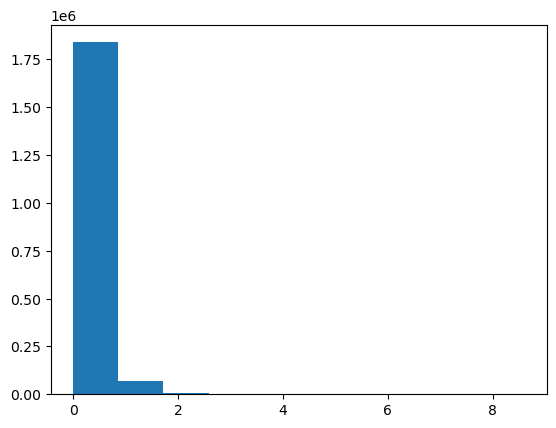

In [54]:
plt.hist(df["CV"])

plt.show()

In [55]:
df['delta'].describe()

count    1.920704e+06
mean     6.560376e-02
std      1.300478e-01
min      0.000000e+00
25%      1.036328e-02
50%      2.432071e-02
75%      5.571294e-02
max      1.000000e+00
Name: delta, dtype: float64

In [56]:
df['CV'].describe()

count    1.916061e+06
mean     2.879733e-01
std      2.736395e-01
min      0.000000e+00
25%      1.393989e-01
50%      2.011804e-01
75%      3.298824e-01
max      8.600828e+00
Name: CV, dtype: float64

In [57]:
df[df['delta'] == 1]

,State_1,ZIP5,travel_dir,day_of_week,hours,avg(traffic_volume),median(traffic_volume),stddev(traffic_volume),CV,delta
180,KS,66962,7,3,hour_01,0.352941,0.0,0.522438,1.480240,1.0
331,KS,66777,5,2,hour_03,0.265306,0.0,0.490557,1.849023,1.0
411,VT,03750,1,6,hour_02,0.676471,0.0,0.911894,1.348017,1.0
460,WY,82836,3,2,hour_01,0.361702,0.0,0.987433,2.729961,1.0
461,WY,82441,3,3,hour_01,0.153846,0.0,0.414663,2.695312,1.0
...,...,...,...,...,...,...,...,...,...,...
1919799,KY,42214,1,6,hour_02,0.320000,0.0,0.556776,1.739926,1.0
1919918,AL,36720,3,7,hour_04,0.931034,0.0,1.162849,1.248985,1.0
1920076,ID,83340,5,6,hour_01,0.574468,0.0,1.037235,1.805557,1.0
1920564,WI,54418,7,3,hour_23,0.250000,0.0,0.683130,2.732520,1.0


In [100]:
# Get the ZIP5 in truck data
# Check which ZIP5 in truck doesn't exist in sensor file
# If doesn't exist, either find the nearest one, or take ZIP3

count    120456.000000
mean          0.182033
std           0.124622
min           0.000000
25%           0.119454
50%           0.156016
75%           0.205869
max           4.641575
Name: CV, dtype: float64

In [87]:
search = SearchEngine()


def get_zip(row):
    r = search.by_coordinates(row['lat'], row['lng'], radius=30, returns=1)
    return r[0].zipcode if r else None


model_stop['ZIP5'] = model_stop.apply(get_zip, axis=1)

In [91]:
model_stop[~model_stop["ZIP5"].isin(df["ZIP5"].unique())]

,pin id,pinname,lat,lng,truckParkingSpotCount,f_system,link_id,review_score,amenities_score,overnightParking,ZIP5
4,09bd2862fe3035ad3223816b439045e3,Rest NB,32.905019,-86.634207,10,1,IN0000650000_213.14_213.24,NaN,NaN,1.0,35171
6,0dd2d86400c04c331cc5f7fc2ddc27d6,Pilot Travel Center #1549,33.593139,-86.121191,30,1,IN0000200000_168.161_168.209,NaN,NaN,1.0,35096
7,1019c8091693ef5c5f55970346633f92,Love's Travel Stop #466,33.791080,-87.242461,68,1,IN0000220000_65.114_65.125,NaN,NaN,1.0,35501
8,1061b7ca1205d71fc6353670cef0835b,Parking / jack's,33.597353,-85.929145,11,1,IN0000200000_179.541_179.64,NaN,NaN,1.0,36260
9,11b53f23ad385f735495083c7327faf9,Chilton Co. Rest Area I-65 - Southbound,32.906863,-86.637657,22,1,IN0000650000_213.34_213.44,NaN,NaN,1.0,35171
...,...,...,...,...,...,...,...,...,...,...,...
777,f547650a0bdd2c2aeee4b0fddcc4aa4b,27 Pickston Ln Parking,29.510020,-81.198118,45,1,73001000_7.7_7.8,NaN,NaN,NaN,32164
778,f683900ca17bd492ad987ecf64e8ace6,Southern Bell Truckstop,26.666573,-80.718385,15,3,93100000_12.3_12.4,NaN,NaN,1.0,33493
779,f6a8dd1c954c8506aadc764cc32b895e,Florida's Turnpike Enterprise,28.515972,-81.500981,20,2,75470000_14.5_14.6,NaN,NaN,1.0,32835
780,fa8f329aba0c0ab4887762a0ecbc2c27,JOURNEY FOOD STORE #2 - Mobil,30.569739,-81.835794,18,3,74030000_5.1_5.2,NaN,NaN,0.0,32011


In [92]:
df[df["ZIP5"] == "35171"]

,State_1,ZIP5,travel_dir,day_of_week,hours,avg(traffic_volume),median(traffic_volume),stddev(traffic_volume),CV,delta
